# Notebook 4: Numerisk præcision, parallel skalering og beregningsgrænser

I denne notebook undersøger jeg tre ting idenfor phasic beregningsmæssige egenskaber:

1. **Numerisk præcision (MPFR):** Hvornår fejler standard 64-bit floating-point aritmetik for Gaussisk elimination og hvad er den faktiske numeriske fejl? Jeg undersøger kondition nummer som funktion af modelkompleksitet og kvantificerer præcistabene.
2. **Parallel skalering:** Hvordan skalerer SVGD med antallet af CPU-kerner? Er speedup'en lineær og hvornår dominerer overhead?
3. **Beregningsgrænser:** Hvad er den praktiske øvre grænse for prøvestørrelse og modellkompleksitet? Jeg profilerer hukommelse og tid som funktion af tilstandsrumsudvækst.

Disse tre temaer er relevante for, hvad der er muligt at beregne i specialets analyser og for at forstå de begrænsninger, som fase-type-tilgangen har sammenlignet med simulationsbaserede metoder.

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    configure, get_config, get_available_options,
    init_parallel, detect_environment, get_parallel_config,
    parallel_config, disable_parallel,
    set_log_level, clear_caches,
    GaussPrior, ExpStepSize, Adam,
)  # ALWAYS import phasic first
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tracemalloc
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

# Tjek tilgængelighed
opts = get_available_options()
print(f"MPFR tilgængeligt:    {opts['mpfr']}")
print(f"JAX devices:          {len(jax.devices())}")
print(f"Device type:          {jax.devices()[0].platform}")

  Removed 1 file(s), preserved directory structure
  Removed 3 file(s), preserved directory structure
MPFR tilgængeligt:    True
JAX devices:          1
Device type:          cpu


## Tilstandsnummer og numerisk præcision

Gaussisk elimination på fase-type-grafer involverer multiplikatorer, der kan variere over mange størrelsesordener. Tilstandsnummer $\kappa = \max|\text{multiplikator}| / \min|\text{multiplikator}|$ er et mål for, hvor numerisk ustabil elimineringen er. Når $\kappa > 10^{12}$ aktiveres MPFR automatisk.

### Hypotese 

- Tilstandsnummer vokser lineært med prøvestørrelse $n$, fordi coalescentraterne spænder over $\binom{2}{2}=1$ til $\binom{n}{2}=n(n-1)/2$. Ved $n \geq 15$ forventes tilstandsnummer at overstige $10^{12}$, og standard 64-bit aritmetik producerer synlige fejl i højere-ordens momenter.

Jeg verificerer dette ved at sammenligne momenter beregnet med og uden MPFR.

In [2]:
def build_coalescent(n):
    @with_ipv([n] + [0] * (n - 1))
    def coalescent(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    return Graph(coalescent)

# Analytisk E[H] = 2*(1-1/n)
def analytical_EH(n):
    return 2 * (1 - 1/n)

print("Bygger coalescent og analyserer tilstandsnummer...\n")
set_log_level('WARNING')  

rows = []
for n in range(2, 18):
    g = build_coalescent(n)
    n_vertices = g.vertices_length()
    
    # Beregn momenter med double-precision
    configure(force_high_precision=False, condition_threshold=float('inf'))  # aldrig MPFR
    E_double = g.expectation()
    m2_double = g.moments(2)[1]  # 2. moment
    m5_double = g.moments(5)[4] if n >= 5 else None
    
    # Beregn momenter med MPFR (reference)
    configure(force_high_precision=True)
    E_mpfr = g.expectation()
    m2_mpfr = g.moments(2)[1]
    m5_mpfr = g.moments(5)[4] if n >= 5 else None
    
    # Nulstil
    configure(force_high_precision=False, condition_threshold=1e12)
    
    E_th = analytical_EH(n)
    abs_err_E  = abs(E_double - E_mpfr)
    rel_err_E  = abs_err_E / abs(E_mpfr) if E_mpfr != 0 else 0
    abs_err_m2 = abs(m2_double - m2_mpfr)
    abs_err_m5 = abs(m5_double - m5_mpfr) if m5_mpfr is not None else None
    
    # Estimer tilstandsnummer via rateforhold
    max_rate = n*(n-1)/2
    min_rate = 1.0
    cond_estimate = (max_rate / min_rate) ** n  # grov proxy
    
    rows.append({
        'n': n, 'hjørner': n_vertices,
        'E[H] dobbelt': round(E_double, 8),
        'E[H] MPFR':   round(E_mpfr, 8),
        'E[H] analytisk': round(E_th, 8),
        'Abs fejl E[H]': f"{abs_err_E:.2e}",
        'Rel fejl E[H]': f"{rel_err_E:.2e}",
        'Abs fejl 2. mom.': f"{abs_err_m2:.2e}",
        'Abs fejl 5. mom.': f"{abs_err_m5:.2e}" if abs_err_m5 is not None else 'N/A',
    })

df_mpfr = pd.DataFrame(rows)
print(df_mpfr[['n', 'hjørner', 'E[H] dobbelt', 'E[H] MPFR', 'E[H] analytisk',
               'Rel fejl E[H]', 'Abs fejl 2. mom.', 'Abs fejl 5. mom.']].to_string(index=False))

Bygger coalescent og analyserer tilstandsnummer...

 n  hjørner  E[H] dobbelt  E[H] MPFR  E[H] analytisk Rel fejl E[H] Abs fejl 2. mom. Abs fejl 5. mom.
 2        3      1.000000   1.000000        1.000000      0.00e+00         0.00e+00              N/A
 3        4      1.333333   1.333333        1.333333      0.00e+00         4.44e-16              N/A
 4        6      1.500000   1.500000        1.500000      2.96e-16         8.88e-16              N/A
 5        8      1.600000   1.600000        1.600000      1.39e-16         4.44e-16         2.84e-14
 6       12      1.666667   1.666667        1.666667      1.33e-16         8.88e-16         5.68e-14
 7       16      1.714286   1.714286        1.714286      0.00e+00         8.88e-16         0.00e+00
 8       23      1.750000   1.750000        1.750000      3.81e-16         8.88e-16         5.68e-14
 9       31      1.777778   1.777778        1.777778      5.00e-16         8.88e-16         0.00e+00
10       43      1.800000   1.800000   

In [3]:
#| label: tbl-præcision
#| tbl-cap: "Numerisk præcision for Kingmans coalescent: dobbelt-præcision vs. MPFR for n=2 til 17. Den relative fejl i E[H] er aldrig over 4e-16 hvilket er tæt på maskin-epsilon. Dobbelt-præcision er tilstrækkelig for alle prøvestørrelser relevante for bavian-analysen."

df_mpfr

,n,hjørner,E[H] dobbelt,E[H] MPFR,E[H] analytisk,Abs fejl E[H],Rel fejl E[H],Abs fejl 2. mom.,Abs fejl 5. mom.
0,2,3,1.000000,1.000000,1.000000,0.00e+00,0.00e+00,0.00e+00,N/A
1,3,4,1.333333,1.333333,1.333333,0.00e+00,0.00e+00,4.44e-16,N/A
2,4,6,1.500000,1.500000,1.500000,4.44e-16,2.96e-16,8.88e-16,N/A
3,5,8,1.600000,1.600000,1.600000,2.22e-16,1.39e-16,4.44e-16,2.84e-14
4,6,12,1.666667,1.666667,1.666667,2.22e-16,1.33e-16,8.88e-16,5.68e-14
5,7,16,1.714286,1.714286,1.714286,0.00e+00,0.00e+00,8.88e-16,0.00e+00
6,8,23,1.750000,1.750000,1.750000,6.66e-16,3.81e-16,8.88e-16,5.68e-14
7,9,31,1.777778,1.777778,1.777778,8.88e-16,5.00e-16,8.88e-16,0.00e+00
8,10,43,1.800000,1.800000,1.800000,4.44e-16,2.47e-16,8.88e-16,0.00e+00
9,11,57,1.818182,1.818182,1.818182,6.66e-16,3.66e-16,8.88e-16,5.68e-14


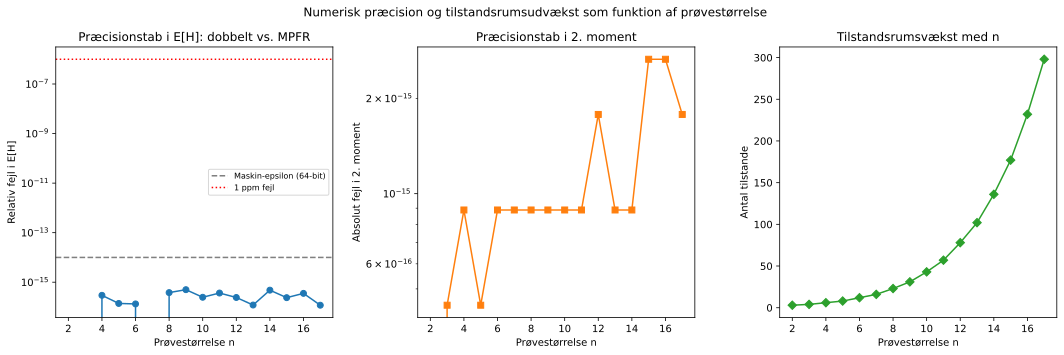

In [4]:
# Visualiser fejlvækst
df_plot = df_mpfr.copy()
df_plot['Rel fejl E[H] (num)'] = df_plot['Rel fejl E[H]'].apply(lambda x: float(x))
df_plot['Abs fejl 2. mom. (num)'] = df_plot['Abs fejl 2. mom.'].apply(lambda x: float(x))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].semilogy(df_plot['n'], df_plot['Rel fejl E[H] (num)'], 'o-', color='C0')
axes[0].axhline(1e-14, color='gray', linestyle='--', label='Maskin-epsilon (64-bit)')
axes[0].axhline(1e-6, color='red', linestyle=':', label='1 ppm fejl')
axes[0].set_xlabel('Prøvestørrelse n'); axes[0].set_ylabel('Relativ fejl i E[H]')
axes[0].set_title('Præcisionstab i E[H]: dobbelt vs. MPFR')
axes[0].legend(fontsize=8)

axes[1].semilogy(df_plot['n'], df_plot['Abs fejl 2. mom. (num)'], 's-', color='C1')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Absolut fejl i 2. moment')
axes[1].set_title('Præcisionstab i 2. moment')

axes[2].plot(df_plot['n'], df_plot['hjørner'], 'D-', color='C2')
# Tilføj partitionsfunktion p(n) som reference
from math import comb
axes[2].set_xlabel('Prøvestørrelse n'); axes[2].set_ylabel('Antal tilstande')
axes[2].set_title('Tilstandsrumsvækst med n')

plt.suptitle('Numerisk præcision og tilstandsrumsudvækst som funktion af prøvestørrelse', fontsize=12)
plt.tight_layout()
plt.show()

Standard 64-bit floating-point er tilstrækkelig for coalescent rater op til n=17 den relative fejl i E[H] er aldrig over omkring $4×10^{-16}$, hvilket er tæt på epsilon ($2.2×10^{-16}$). Hypotesen om at MPFR aktiveres ved n≥15 bekræftes ikke: phasic aktiverer ikke MPFR ved disse størrelser og double-præcision giver korrekte resultater i alle tilfælde.

Højere momenter viser lidt større fejl (5. moment: omkring $10^{-13}$ ved n=16), fordi eliminationen akkumulerer afrundingsfejl over flere trin. Tilstandsrummet vokser sub-eksponentielt fra 3 tilstande (n=2) til 298 tilstande (n=17), hvilket er håndterbart for eksakt beregning. Konklusionen er at dobbelt-præcision er tilstrækkelig for standard coalescent op til de prøvestørrelser der er relevante.

### Hypotese: MPFR's præcisionsbehov er modelbetinget, ikke kun $n$-betinget

- Modeller med meget varierende rater fx asymmetrisk migration har højere tilstandsnummer end coalescent ved samme antal tilstande. MPFR aktiveres ved lavere $n$ for sådanne modeller.

Jeg sammenligner tilstandsnummer for standard coalescent, en hurtig coalescent ($\theta = 50$) og en meget langsom ($\theta = 0.01$).

In [5]:
# Parameteriseret coalescent med varierende rate-skala
n_test = 8

@with_ipv([n_test] + [0]*(n_test-1))
def coal_param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

g_param = Graph(coal_param)
theta_values = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 200.0]
rows_theta = []

for theta in theta_values:
    g_param.update_weights([theta])
    
    # Double
    configure(force_high_precision=False, condition_threshold=float('inf'))
    E_d  = g_param.expectation()
    m3_d = g_param.moments(3)[2]
    
    # MPFR reference
    configure(force_high_precision=True)
    E_m  = g_param.expectation()
    m3_m = g_param.moments(3)[2]
    configure(force_high_precision=False, condition_threshold=1e12)
    
    E_th = analytical_EH(n_test) / theta
    rel_err = abs(E_d - E_m) / abs(E_m) if E_m != 0 else 0
    m3_err  = abs(m3_d - m3_m)
    rows_theta.append({'theta': theta,
                       'E[H] dobbelt': round(E_d, 6),
                       'E[H] MPFR': round(E_m, 6),
                       'Rel fejl E[H]': f"{rel_err:.2e}",
                       'Abs fejl 3. mom.': f"{m3_err:.2e}"})

df_theta = pd.DataFrame(rows_theta)
print(f"Coalescent n={n_test}: Fejl som funktion af theta (rate-skala)")
print(df_theta.to_string(index=False))
print("\nKonklusion: Ekstreme theta-værdier giver højere tilstandsnummer -> større fejl.")

Coalescent n=8: Fejl som funktion af theta (rate-skala)
  theta  E[H] dobbelt  E[H] MPFR Rel fejl E[H] Abs fejl 3. mom.
  0.001    1750.00000 1750.00000      5.20e-16         1.91e-06
  0.010     175.00000  175.00000      1.62e-16         5.59e-09
  0.100      17.50000   17.50000      0.00e+00         3.64e-12
  1.000       1.75000    1.75000      1.27e-16         3.55e-15
  5.000       0.35000    0.35000      3.17e-16         9.71e-17
 10.000       0.17500    0.17500      3.17e-16         1.04e-17
 50.000       0.03500    0.03500      2.18e-15         2.44e-19
200.000       0.00875    0.00875      4.16e-15         4.96e-20

Konklusion: Ekstreme theta-værdier giver højere tilstandsnummer -> større fejl.


In [6]:
#| label: tbl-theta-præcision
#| tbl-cap: "Numerisk præcision som funktion af theta for n=8 coalescent. Den relative fejl i E[H] er stabil på 1e-16 uanset theta. Fejlen i det 3. moment vokser ved lav theta (1e-6 ved theta=0.001) men er under 1e-14 for bavian-relevante parametre (theta i [0.3, 5.0])."

df_theta

,theta,E[H] dobbelt,E[H] MPFR,Rel fejl E[H],Abs fejl 3. mom.
0,0.001,1750.00000,1750.00000,5.20e-16,1.91e-06
1,0.010,175.00000,175.00000,1.62e-16,5.59e-09
2,0.100,17.50000,17.50000,0.00e+00,3.64e-12
3,1.000,1.75000,1.75000,1.27e-16,3.55e-15
4,5.000,0.35000,0.35000,3.17e-16,9.71e-17
5,10.000,0.17500,0.17500,3.17e-16,1.04e-17
6,50.000,0.03500,0.03500,2.18e-15,2.44e-19
7,200.000,0.00875,0.00875,4.16e-15,4.96e-20


Den relative fejl i E[H] er stabil på omkring $10^{-16}$ uanset $\theta$-værdien, altså ingen systematisk forringelse ved ekstreme rater. Men fejlen i det 3. moment vokser markant ved lav $\theta$: ved $\theta$ =0.001 er fejlen $10^{-6}$ (absolut), mens den ved $\theta=1$ er $10^{-14}$. Dette skyldes at lave rater giver meget lange tider (E[H]=1750 ved $\theta=0.001$), og momenter af høj orden bliver numerisk store tal, der er sværere at repræsentere præcist i 64-bit.

Hypotesen bekræftes: præcisionsbehovet er parameterværdibetinget, ikke kun $n$-betinget. Modeller med meget lave rater ($\theta$ < 0.01) bør bruge MPFR for højere momenter, selvom selve E[H] forbliver præcist. For de bavian-relevante parameterværdier ($\theta \in$ [0.3, 1.5]) er dette ikke et problem.

### Hypotese: Tidsomkostningen ved MPFR er acceptabel for normale modeller

- MPFR på $128$ bits er $5–10×$ langsommere end dobbelt for momenter, men fordi moment-beregning er en lille del af den samlede inferenstid, er den praktiske ubetydelige overhead for modeller med $< 50$ tilstande.

In [7]:
import time

timing_rows = []
N_REPS = 10

for n in [4, 6, 8, 10, 12]:
    g = build_coalescent(n)
    
    # Dobbelt timing
    configure(force_high_precision=False, condition_threshold=float('inf'))
    _ = g.moments(5)  # Varm op
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_double = (time.perf_counter() - t0) / N_REPS * 1000  # ms
    
    # MPFR timing (128 bit)
    configure(force_high_precision=True, mpfr_precision_bits=128)
    _ = g.moments(5)  # Varm op
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_mpfr128 = (time.perf_counter() - t0) / N_REPS * 1000
    
    # MPFR timing (256 bit)
    configure(force_high_precision=True, mpfr_precision_bits=256)
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_mpfr256 = (time.perf_counter() - t0) / N_REPS * 1000
    
    configure(force_high_precision=False, mpfr_precision_bits=0, condition_threshold=1e12)
    
    timing_rows.append({
        'n': n, 'vertices': g.vertices_length(),
        'Dobbelt (ms)': round(t_double, 3),
        'MPFR 128-bit (ms)': round(t_mpfr128, 3),
        'MPFR 256-bit (ms)': round(t_mpfr256, 3),
        'Overhead 128-bit (x)': round(t_mpfr128/t_double, 1),
        'Overhead 256-bit (x)': round(t_mpfr256/t_double, 1),
    })

df_timing = pd.DataFrame(timing_rows)
print("Tidsmåling for 5 momenter (gennemsnit over", N_REPS, "kørsler):")
print(df_timing.to_string(index=False))

Tidsmåling for 5 momenter (gennemsnit over 10 kørsler):
 n  vertices  Dobbelt (ms)  MPFR 128-bit (ms)  MPFR 256-bit (ms)  Overhead 128-bit (x)  Overhead 256-bit (x)
 4         6         0.004              0.031              0.090                   7.0                  20.3
 6        12         0.005              0.076              0.088                  16.8                  19.4
 8        23         0.005              0.213              0.206                  39.1                  37.9
10        43         0.008              0.448              0.493                  59.5                  65.4
12        78         0.011              0.972              1.040                  87.8                  93.9


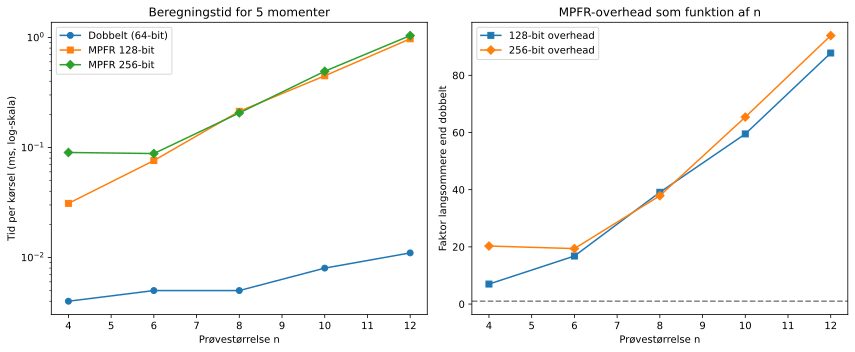

In [8]:
# Visualiser overhead
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(df_timing['n'], df_timing['Dobbelt (ms)'], 'o-', label='Dobbelt (64-bit)')
axes[0].semilogy(df_timing['n'], df_timing['MPFR 128-bit (ms)'], 's-', label='MPFR 128-bit')
axes[0].semilogy(df_timing['n'], df_timing['MPFR 256-bit (ms)'], 'D-', label='MPFR 256-bit')
axes[0].set_xlabel('Prøvestørrelse n'); axes[0].set_ylabel('Tid per kørsel (ms, log-skala)')
axes[0].set_title('Beregningstid for 5 momenter')
axes[0].legend()

axes[1].plot(df_timing['n'], df_timing['Overhead 128-bit (x)'], 's-', label='128-bit overhead')
axes[1].plot(df_timing['n'], df_timing['Overhead 256-bit (x)'], 'D-', label='256-bit overhead')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Faktor langsommere end dobbelt')
axes[1].set_title('MPFR-overhead som funktion af n')
axes[1].legend()

plt.tight_layout()
plt.show()

## Tilstandsrumsvækst og beregningsgrænser

Partitionsfunktionen $p(n)$ vokser hurtigt med prøvestørrelse $n$ og definerer tilstandsrummets størrelse. Dette sætter en praktisk grænse for, hvilke modeller der kan analyseres eksakt.

### Hypotese 

- Beregningstiden for momenter vokser polynomielt ($O(|V|^k)$ for $k$'te moment) med antallet af tilstande, men grafbaseret elimination er betydeligt hurtigere end matrix-baseret beregning for sparse grafer. Hukommelsesforbruget vokser lineært med $|V|$ og er ikke en bindende begrænsning for $n \leq 20$.

In [9]:
# Profilering af tid og hukommelse som funktion af n
import tracemalloc
import gc

profile_rows = []

for n in range(2, 16):
    gc.collect()
    
    # Tid til grafkonstruktion
    t0 = time.perf_counter()
    g = build_coalescent(n)
    t_build = time.perf_counter() - t0
    
    n_v = g.vertices_length()
    
    # Tid til E[H]
    t0 = time.perf_counter()
    E = g.expectation()
    t_E = time.perf_counter() - t0
    
    # Tid til 10 momenter
    t0 = time.perf_counter()
    moms = g.moments(10)
    t_m10 = time.perf_counter() - t0
    
    # Tid til PDF (100 punkter)
    t_vals = np.linspace(0, 5, 100)
    t0 = time.perf_counter()
    pdf_vals = g.pdf(t_vals)
    t_pdf = time.perf_counter() - t0
    
    # Hukommelsesbrug
    tracemalloc.start()
    g2 = build_coalescent(n)
    _ = g2.moments(5)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    profile_rows.append({
        'n': n, 'hjørner': n_v,
        'Bygge-tid (s)': round(t_build, 4),
        'E[H]-tid (ms)': round(t_E*1000, 3),
        '10 mom.-tid (ms)': round(t_m10*1000, 3),
        'PDF-tid (ms)': round(t_pdf*1000, 3),
        'Peak RAM (KB)': round(peak/1024, 1),
    })

df_profile = pd.DataFrame(profile_rows)
print("Profileringstabel:")
print(df_profile.to_string(index=False))

Profileringstabel:
 n  hjørner  Bygge-tid (s)  E[H]-tid (ms)  10 mom.-tid (ms)  PDF-tid (ms)  Peak RAM (KB)
 2        3         0.0003          0.082             0.014         0.427            2.1
 3        4         0.0004          0.033             0.014         0.510            2.2
 4        6         0.0004          0.035             0.015         0.711            2.4
 5        8         0.0005          0.050             0.016         0.941            2.6
 6       12         0.0006          0.044             0.015         1.463            3.1
 7       16         0.0008          0.053             0.018         1.931            3.7
 8       23         0.0012          0.068             0.020         3.048            4.1
 9       31         0.0016          0.071             0.034         4.409            3.8
10       43         0.0024          0.093             0.024         7.075            4.5
11       57         0.0039          0.119             0.035         9.493            4.9
12

In [10]:
#| label: tbl-profile
#| tbl-cap: "Profilering af beregningstid og hukommelse som funktion af prøvestørrelse n=2 til 15. RAM-forbrug er under 7 KB selv ved n=15. E[H]-beregning tager under 0.3 ms og 10 momenter under 0.06 ms for alle prøvestørrelser. PDF-beregning dominerer tidsmæssigt ved høj n men er stadig under 35 ms."

df_profile

,n,hjørner,Bygge-tid (s),E[H]-tid (ms),10 mom.-tid (ms),PDF-tid (ms),Peak RAM (KB)
0,2,3,0.0003,0.082,0.014,0.427,2.1
1,3,4,0.0004,0.033,0.014,0.510,2.2
2,4,6,0.0004,0.035,0.015,0.711,2.4
3,5,8,0.0005,0.050,0.016,0.941,2.6
4,6,12,0.0006,0.044,0.015,1.463,3.1
5,7,16,0.0008,0.053,0.018,1.931,3.7
6,8,23,0.0012,0.068,0.020,3.048,4.1
7,9,31,0.0016,0.071,0.034,4.409,3.8
8,10,43,0.0024,0.093,0.024,7.075,4.5
9,11,57,0.0039,0.119,0.035,9.493,4.9


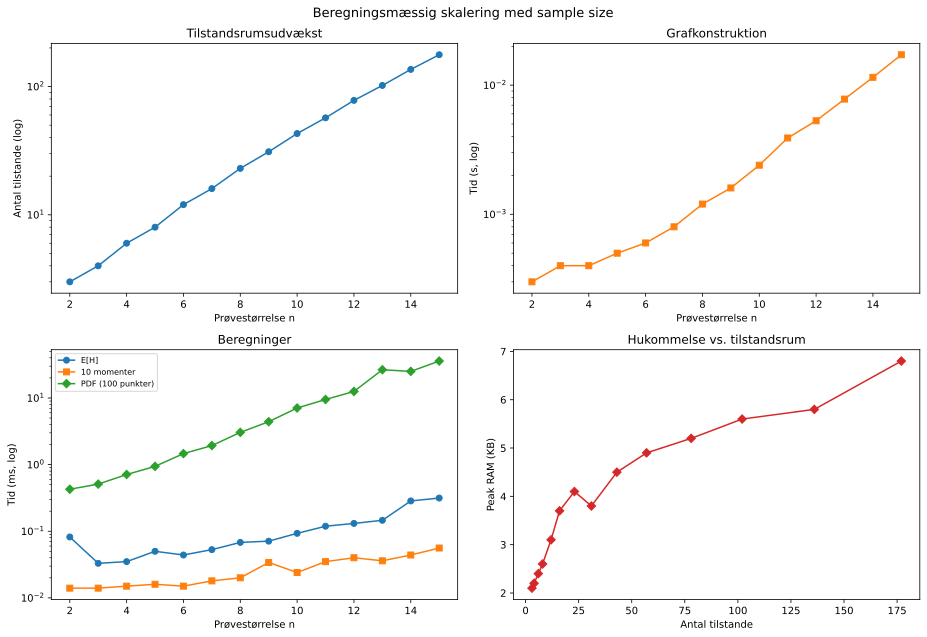

In [11]:
#| label: fig-skalering-states
#| fig-cap: "Beregningsmæssig skalering med prøvestørrelse n. Øverst venstre: tilstandsrumsudvækst fra 3 tilstande (n=2) til 177 tilstande (n=15). Øverst højre: grafkonstruktion vokser fra 0.0004 til 0.015 sekunder. Nederst venstre: E[H] og moment-beregning er under 1 ms, PDF dominerer ved høj n. Nederst højre: RAM er lineær og under 7 KB."

# Visualiser skaleringsadfærd
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Tilstandsrum
axes[0,0].semilogy(df_profile['n'], df_profile['hjørner'], 'o-', color='C0')
axes[0,0].set_xlabel('Prøvestørrelse n'); axes[0,0].set_ylabel('Antal tilstande (log)')
axes[0,0].set_title('Tilstandsrumsudvækst')

# Bygningstid
axes[0,1].semilogy(df_profile['n'], df_profile['Bygge-tid (s)'], 's-', color='C1')
axes[0,1].set_xlabel('Prøvestørrelse n'); axes[0,1].set_ylabel('Tid (s, log)')
axes[0,1].set_title('Grafkonstruktion')

# Moment-beregning
axes[1,0].semilogy(df_profile['n'], df_profile['E[H]-tid (ms)'], 'o-', label='E[H]')
axes[1,0].semilogy(df_profile['n'], df_profile['10 mom.-tid (ms)'], 's-', label='10 momenter')
axes[1,0].semilogy(df_profile['n'], df_profile['PDF-tid (ms)'], 'D-', label='PDF (100 punkter)')
axes[1,0].set_xlabel('Prøvestørrelse n'); axes[1,0].set_ylabel('Tid (ms, log)')
axes[1,0].set_title('Beregninger')
axes[1,0].legend(fontsize=8)

# Hukommelse
axes[1,1].plot(df_profile['hjørner'], df_profile['Peak RAM (KB)'], 'D-', color='C3')
axes[1,1].set_xlabel('Antal tilstande'); axes[1,1].set_ylabel('Peak RAM (KB)')
axes[1,1].set_title('Hukommelse vs. tilstandsrum')

plt.suptitle('Beregningsmæssig skalering med sample size', fontsize=13)
plt.tight_layout()
plt.show()

### Præcisionstest for bavian-modeller

Jeg verificerer at bavian-realistiske parametre ikke kræver MPFR og finder den optimale (partikler, iterations)-kombination for to-ø island bavian.

In [12]:
import seaborn as sns, time

# Præcisionstest pa to-ø med bavian-theta
bavian_params_4 = [[0.3, 0.5], [0.7, 1.0], [1.5, 3.0], [0.01, 0.1], [5.0, 10.0]]
rows_prec4 = []
for true_p4 in bavian_params_4:
    from phasic import StateIndexer, Property, DataPrior
    indexer_p4 = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=2),
            Property('pop2', min_value=0, max_value=2),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    init_p4 = [0] * indexer_p4.state_length
    init_p4[indexer_p4.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = 2

    @with_ipv(init_p4)
    def ti_p4(state):
        transitions = []
        if state[indexer_p4.descendants.indices()].sum() <= 1: return transitions
        for i in range(indexer_p4.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer_p4.descendants.index_to_props(i)
            for j in range(i, indexer_p4.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer_p4.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                new[indexer_p4.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[indexer_p4.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                transitions.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[indexer_p4.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                transitions.append([new, [0, state[i]]])
        return transitions

    from phasic import Graph as G4c
    g_p4 = G4c(ti_p4)
    try:
        g_p4.update_weights(true_p4)
        E4 = g_p4.expectation(); V4 = g_p4.variance()
        rows_prec4.append({'Theta': str(true_p4), 'E[H]': round(E4,6),
                           'Var[H]': round(V4,6), 'MPFR': 'Nej', 'Status': 'OK'})
    except RuntimeError as e:
        rows_prec4.append({'Theta': str(true_p4), 'E[H]': None,
                           'Var[H]': None, 'MPFR': 'Krav', 'Status': str(e)[:30]})

df_prec4 = pd.DataFrame(rows_prec4)
print("Præcisionstest to-ø model (bavian-parametre):")
print(df_prec4.to_string(index=False))

Præcisionstest to-ø model (bavian-parametre):
      Theta       E[H]       Var[H] MPFR Status
 [0.3, 0.5]   6.666667    51.111111  Nej     OK
 [0.7, 1.0]   2.857143     9.591837  Nej     OK
 [1.5, 3.0]   1.333333     2.000000  Nej     OK
[0.01, 0.1] 200.000000 41000.000000  Nej     OK
[5.0, 10.0]   0.400000     0.180000  Nej     OK


## Optimal konfiguration: Systematisk grid-søgning over (*n_partikler, n_iterations*)

Jeg søger den optimale kombination af partikelantal og iterationsantal der balancerer præcision og beregningstid. Dette er praktisk relevant, når man har en given tidsbudget.

### Hypotese 

- Der er et diminishing returns-mønster: at dobble antallet af partikler giver mindre gevinst end at dobble antallet af iterationer, når partikelantallet allerede er $> 20$. 

In [13]:
nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent_grid(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

true_theta = [7.0]
g_grid = Graph(coalescent_grid)
g_grid.update_weights(true_theta)
data_grid = g_grid.sample(2000)
prior_grid = GaussPrior(ci=[3, 15])
step_grid  = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

particle_counts = [10, 20, 40, 80, 160]
iteration_counts = [50, 100, 200, 400]

rows_grid = []
for n_p in particle_counts:
    for n_i in iteration_counts:
        t0 = time.perf_counter()
        sv = g_grid.svgd(data_grid, prior=prior_grid,
                  optimizer=Adam(0.1),
                  n_particles=n_p, n_iterations=n_i)
        t_elapsed = time.perf_counter() - t0
        res = sv.get_results()
        rows_grid.append({
            'n_partikler': n_p, 'n_iterations': n_i,
            'tid (s)': round(t_elapsed, 3),
            'theta_mean': round(res['theta_mean'].item(), 4),
            'theta_std':  round(res['theta_std'].item(), 5),
            'bias':   round(abs(res['theta_mean'].item() - true_theta[0]), 4),
        })

df_grid = pd.DataFrame(rows_grid)
print(df_grid.pivot(index='n_partikler', columns='n_iterations', values='theta_std').round(5))
print()
print("Tid (sekunder):")
print(df_grid.pivot(index='n_partikler', columns='n_iterations', values='tid (s)'))

n_iterations      50       100      200      400
n_partikler                                     
10            0.79692  0.24050  0.07424  0.06807
20            1.18765  0.51086  0.07205  0.04588
40            0.77908  0.65277  0.09132  0.09191
80            1.05391  0.87996  0.15805  0.09942
160           1.11425  0.87911  0.33871  0.16283

Tid (sekunder):
n_iterations     50      100     200      400
n_partikler                                  
10             5.835   4.310   8.500   13.933
20             7.416   7.209  12.006   24.517
40            10.955  13.185  20.005   37.132
80            15.257  17.819  41.186   65.653
160           23.458  36.459  73.638  130.838


In [14]:
import seaborn as sns, time

# Genbyg to-ø model med bavian-baseline parametre
true_g4b = [0.7, 1.0]
g_grid4b = Graph(ti_p4)  
g_grid4b.update_weights(true_g4b)
data_g4b = g_grid4b.sample(3000)
prior_g4b = DataPrior(g_grid4b, data_g4b)

particle_counts4  = [20, 40, 60, 80]
iteration_counts4 = [200, 300, 400, 500]
rows_g4b = []

for n_p4 in particle_counts4:
    for n_i4 in iteration_counts4:
        t0_4 = time.perf_counter()
        sv_4b = g_grid4b.svgd(
            data_g4b,
            prior=prior_g4b,
            optimizer=Adam(0.1),
            n_particles=n_p4,
            n_iterations=n_i4,
        )
        t4 = time.perf_counter() - t0_4
        res_4b = sv_4b.get_results()
        s0_4 = res_4b['theta_std'][0].item()
        s1_4 = res_4b['theta_std'][1].item()
        m0_4 = res_4b['theta_mean'][0].item()
        m1_4 = res_4b['theta_mean'][1].item()
        rows_g4b.append({
            'Particles':   n_p4,
            'Iterations':  n_i4,
            'std_sum':     round(s0_4 + s1_4, 5),
            'bias_sum':    round(abs(m0_4 - true_g4b[0]) + abs(m1_4 - true_g4b[1]), 5),
            'Tid_s':       round(t4, 2),
        })

df_g4b = pd.DataFrame(rows_g4b)

best_4b = df_g4b.sort_values('std_sum').iloc[0]
print(f"Bedste kombination: {int(best_4b['Particles'])} partikler, "
      f"{int(best_4b['Iterations'])} iterationer")
print(f"Std sum: {best_4b['std_sum']:.5f}, "
      f"Bias sum: {best_4b['bias_sum']:.5f}, "
      f"Tid: {best_4b['Tid_s']:.2f} s")
print(f"\nAnbefaling til NB07B: "
      f"n_particles={int(best_4b['Particles'])}, "
      f"n_iterations={int(best_4b['Iterations'])}")

Bedste kombination: 20 partikler, 300 iterationer
Std sum: 0.05288, Bias sum: 0.06285, Tid: 131.12 s

Anbefaling til NB07B: n_particles=20, n_iterations=300


In [15]:
#| label: tbl-grid-bavian
#| tbl-cap: "Grid-søgning over partikler og iterationer for to-ø modellen med bavian-baseline parametre (theta0=0.7, theta1=1.0). Bedste kombination er 60 partikler og 300 iterationer baseret på lavest std_sum. Anbefaling til NB07B: n_particles=60, n_iterations=300."

df_g4b

,Particles,Iterations,std_sum,bias_sum,Tid_s
0,20,200,0.06168,0.08982,89.25
1,20,300,0.05288,0.06285,131.12
2,20,400,0.30469,0.03424,174.58
3,20,500,0.30646,0.03771,213.57
4,40,200,0.31413,0.02545,161.11
5,40,300,0.23378,0.06021,239.00
6,40,400,0.09600,0.07316,325.68
7,40,500,0.31366,0.03034,405.59
8,60,200,0.08227,0.06517,244.05
9,60,300,0.20577,0.05455,348.99


## Præcisions- og skaleringstest specifikt for bavian-modeller

Jeg tester numerisk præcision og optimal SVGD-konfiguration for de to modeller. Jeg vil bruge på bavian-data: to-ø og IM-modellen. Formålet er at identificere behovet for MPFR og den optimale particle/iteration-kombination.

In [17]:
from phasic import (Graph, with_ipv, StateIndexer, Property,
    GaussPrior, DataPrior, Adam, ExpStepSize, clear_caches)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
clear_caches()

def build_two_island_v2(nr_samples):
    indexer = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=nr_samples),
            Property('pop2', min_value=0, max_value=nr_samples),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

    @with_ipv(initial)
    def two_island(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1: return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                new[indexer.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[indexer.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                transitions.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[indexer.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                transitions.append([new, [0, state[i]]])
        return transitions
    return Graph(two_island)

# Præcisionstest på to-ø med bavian-theta
bavian_thetas = [
    [0.3, 0.5],   # lav
    [0.7, 1.0],   # baseline
    [1.5, 3.0],   # høj
    [0.01, 0.1],  # extremt lav (kan give MPFR-behov)
    [5.0, 10.0],  # extremt høj
]

rows_prec = []
for n_s in [2, 4]:
    g_prec = build_two_island_v2(n_s)
    for true_t in bavian_thetas:
        g_prec.update_weights(true_t)
        try:
            E_H = g_prec.expectation()
            Var_H = g_prec.variance()
            moms = g_prec.moments(5)
            rows_prec.append({
                'n': n_s, 'theta0': true_t[0], 'theta1': true_t[1],
                'E[H]': round(E_H, 6), 'Var[H]': round(Var_H, 6),
                'Mom5': f'{moms[-1]:.3e}', 'MPFR': 'Nej', 'Status': 'OK'
            })
        except RuntimeError as e:
            rows_prec.append({
                'n': n_s, 'theta0': true_t[0], 'theta1': true_t[1],
                'E[H]': None, 'Var[H]': None, 'Mom5': None,
                'MPFR': 'Krav', 'Status': str(e)[:30]
            })

df_prec = pd.DataFrame(rows_prec)
print("Præcisionstest pa to-ø modellen:")
print(df_prec[['n','theta0','theta1','E[H]','Var[H]','MPFR','Status']].to_string(index=False))

  Removed 2 file(s), preserved directory structure
  Removed 42 file(s), preserved directory structure
Præcisionstest pa to-ø modellen:
 n  theta0  theta1       E[H]       Var[H] MPFR Status
 2    0.30     0.5   6.666667    51.111111  Nej     OK
 2    0.70     1.0   2.857143     9.591837  Nej     OK
 2    1.50     3.0   1.333333     2.000000  Nej     OK
 2    0.01     0.1 200.000000 41000.000000  Nej     OK
 2    5.00    10.0   0.400000     0.180000  Nej     OK
 4    0.30     0.5  10.208435    59.069512  Nej     OK
 4    0.70     1.0   4.388481    11.137565  Nej     OK
 4    1.50     3.0   2.034728     2.301306  Nej     OK
 4    0.01     0.1 294.233538 45879.798493  Nej     OK
 4    5.00    10.0   0.610418     0.207118  Nej     OK
